In [5]:
#Carga de datos y exploración inicial
dfc = pd.read_csv('../data/house-prices-tp.csv')
df = dfc.copy()
print("\nInfo dataset original:\n")
df.info()



Info dataset original:

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [6]:
#Cambiamos el tipo de variable de CHAS a int
#df['CHAS'] = df['CHAS'].astype(int)
df['CHAS'].isnull().sum()
print("\n")
print("#"*70)
print("Primeras 10 filas de df:")
print("#"*70)
print(df.head(10))



Info dataset original:

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [8]:
print("#"*90)
print("Describe de df:")
print("#"*90)
print(df.describe().T)

##########################################################################################
Describe de df:
##########################################################################################
         count        mean         std        min        25%         50%  \
CRIM     533.0    5.845517   13.828631    0.00632    0.08447    0.315330   
ZN       534.0   13.197175   24.902981    0.00000    0.00000    0.000000   
INDUS    541.0   11.218725    6.942021    0.46000    5.13000    9.690000   
CHAS     533.0    0.090056    0.286531    0.00000    0.00000    0.000000   
NOX      532.0    0.560050    0.119472    0.38500    0.45300    0.538000   
RM       535.0    6.291839    0.782403    3.56100    5.87550    6.208000   
AGE      532.0   67.632303   28.461925    2.90000   42.27500   76.500000   
DIS      541.0    3.944102    2.255689    1.12960    2.11210    3.340107   
RAD      528.0    9.699379    8.684495    1.00000    4.00000    5.000000   
TAX      538.0  409.575089  167.689379  18

In [9]:

#Verificamos si hay registros duplicados
duplicados = df.duplicated().sum()
print("#"*70)
print(f"Cantidad de registros duplicados: {duplicados}")

nulos_por_columna = df.isna().sum()
print("#"*70)
print("Cantidad de nulos por columna:")
print("#"*70)
print(nulos_por_columna)


nulos_por_fila = df.isna().sum(axis=1)
print("#"*70)
print("Cantidad de nulos por fila:")
print("#"*70)
print(nulos_por_fila.value_counts().sort_index())

######################################################################
Cantidad de registros duplicados: 0
######################################################################
Cantidad de nulos por columna:
######################################################################
CRIM       23
ZN         22
INDUS      15
CHAS       23
NOX        24
RM         21
AGE        24
DIS        15
RAD        28
TAX        18
PTRATIO    28
B          22
LSTAT      22
MEDV       21
dtype: int64
######################################################################
Cantidad de nulos por fila:
######################################################################
0     506
1       5
2       3
3      11
4       3
5       3
6       2
7       5
8       4
9       4
10      1
11      3
12      2
13      3
14      1
Name: count, dtype: int64


In [10]:


# Filtra las filas que acumulan más de 5 NaN
filas_mas_5_nulos = df[df.isna().sum(axis=1) > 5]
print(" ")
print("#"*70)
print (f"Filas con más de 5 nulos: {len(filas_mas_5_nulos)}")
print("#"*70)
print(filas_mas_5_nulos)

 
######################################################################
Filas con más de 5 nulos: 25
######################################################################
          CRIM         ZN      INDUS  CHAS       NOX        RM        AGE  \
37         NaN        NaN        NaN   NaN       NaN       NaN  98.531853   
42   33.205263        NaN   0.595217   0.0       NaN       NaN        NaN   
61         NaN  63.533757        NaN   NaN       NaN  5.445590        NaN   
88         NaN  51.406681        NaN   NaN       NaN       NaN   8.022743   
98         NaN  87.921671        NaN   NaN       NaN  4.594538  40.944091   
187        NaN        NaN        NaN   NaN       NaN       NaN        NaN   
203   2.087555        NaN   3.773124   NaN       NaN       NaN  72.487706   
223        NaN        NaN  15.523638   NaN       NaN       NaN  35.540367   
234  24.222793        NaN  26.380774   NaN  0.454307  4.649042        NaN   
248        NaN        NaN        NaN   0.0       NaN  5.7

In [11]:


#Removemos las filas con más de 5 nulos
df_filtrado = df.drop(filas_mas_5_nulos.index).reset_index(drop=True)

print("#"*70)
print("Información de df_filtrado (luego de remover filas con > 5 NaNs):")
print("#"*70)
df_filtrado.info()

print("#"*70)
print("Listado de registros MEDV sin precios (Target):")
print("#"*70)
print(df_filtrado[df_filtrado['MEDV'].isnull()])

######################################################################
Información de df_filtrado (luego de remover filas con > 5 NaNs):
######################################################################
<class 'pandas.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     525 non-null    float64
 1   ZN       524 non-null    float64
 2   INDUS    530 non-null    float64
 3   CHAS     527 non-null    float64
 4   NOX      527 non-null    float64
 5   RM       528 non-null    float64
 6   AGE      523 non-null    float64
 7   DIS      529 non-null    float64
 8   RAD      521 non-null    float64
 9   TAX      525 non-null    float64
 10  PTRATIO  523 non-null    float64
 11  B        527 non-null    float64
 12  LSTAT    527 non-null    float64
 13  MEDV     527 non-null    float64
dtypes: float64(14)
memory usage: 58.2 KB
################################################

In [12]:
"""
#Removemos registros sin precios. Son pocos (4)
df_filtrado = df_filtrado.dropna(subset=['MEDV']).reset_index(drop=True)

print("#"*70)
print("info() de df_filtrado (se remueven registros MEDV=NaN)")
print("#"*70)
print(df_filtrado.info())
print("#"*70)
print("Describe de df_filtrado:")
print("#"*70)
print(df_filtrado.describe().T)
"""

######################################################################
info() de df_filtrado (se remueven registros MEDV=NaN)
######################################################################
<class 'pandas.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     521 non-null    float64
 1   ZN       521 non-null    float64
 2   INDUS    526 non-null    float64
 3   CHAS     525 non-null    float64
 4   NOX      523 non-null    float64
 5   RM       525 non-null    float64
 6   AGE      520 non-null    float64
 7   DIS      525 non-null    float64
 8   RAD      519 non-null    float64
 9   TAX      522 non-null    float64
 10  PTRATIO  522 non-null    float64
 11  B        523 non-null    float64
 12  LSTAT    523 non-null    float64
 13  MEDV     527 non-null    float64
dtypes: float64(14)
memory usage: 57.8 KB
None
######################################################

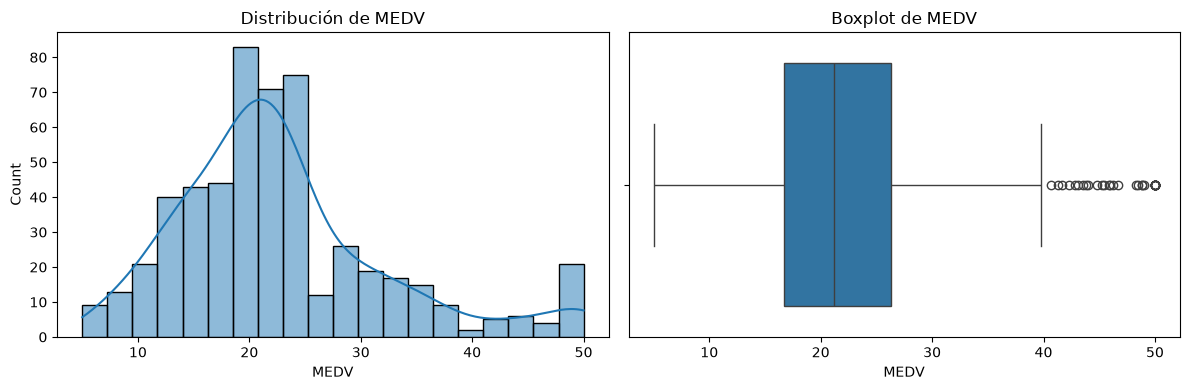

In [14]:

# Visualización de la distribución de la variable objetivo (MEDV)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["MEDV"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distribución de MEDV")
sns.boxplot(x=df["MEDV"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de MEDV")
plt.tight_layout()
#plt.savefig('./outputs/distribucion_medv_pre_imputacion.png', dpi=200)
plt.show()

<Figure size 1800x1200 with 0 Axes>

<Figure size 1800x1200 with 0 Axes>

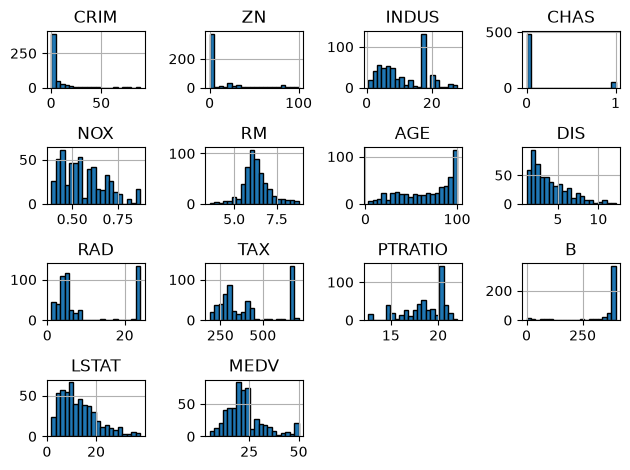

In [15]:



# Histograma de cada variable numérica
plt.figure(figsize=(18, 12))
df_filtrado.hist(bins=20, edgecolor='black')
plt.tight_layout()
#plt.savefig('./outputs/histogramas_variables_pre_imputacion.png', dpi=200)
plt.show()


In [16]:



#A los valores faltanes se les imputa el valor de sus medianas
df_filtrado = df_filtrado.fillna(df_filtrado.median())
print("#"*70)
print("info() de df_filtrado imputando medianas")
print("#"*70)
print(df_filtrado.info())
print("#"*70)
print("Describe de df_filtrado imputando medianas")
print("#"*70)
print(df_filtrado.describe().T)
print("#"*70)


######################################################################
info() de df_filtrado imputando medianas
######################################################################
<class 'pandas.DataFrame'>
RangeIndex: 527 entries, 0 to 526
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     527 non-null    float64
 1   ZN       527 non-null    float64
 2   INDUS    527 non-null    float64
 3   CHAS     527 non-null    float64
 4   NOX      527 non-null    float64
 5   RM       527 non-null    float64
 6   AGE      527 non-null    float64
 7   DIS      527 non-null    float64
 8   RAD      527 non-null    float64
 9   TAX      527 non-null    float64
 10  PTRATIO  527 non-null    float64
 11  B        527 non-null    float64
 12  LSTAT    527 non-null    float64
 13  MEDV     527 non-null    float64
dtypes: float64(14)
memory usage: 57.8 KB
None
####################################################################

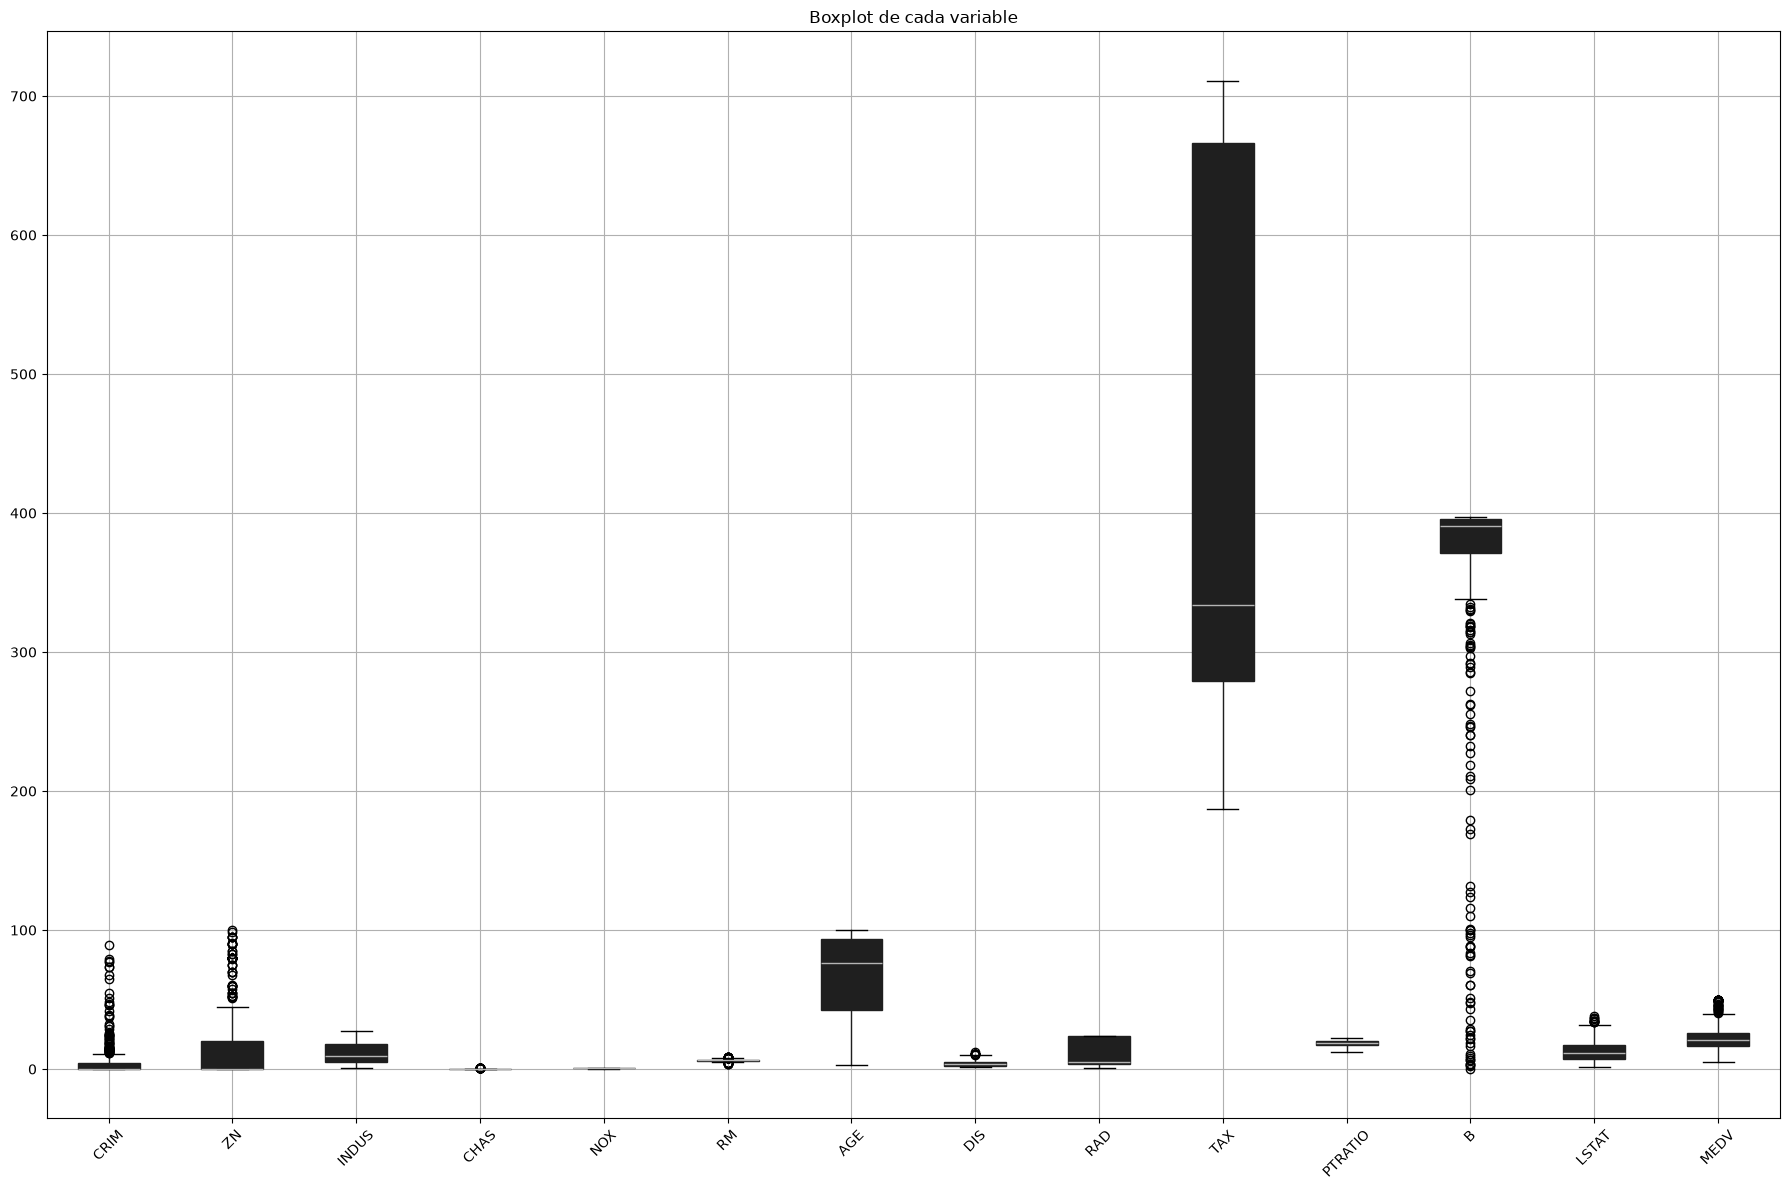

In [51]:
# Boxplot de cada variable para observar cuartiles y outliers
plt.figure(figsize=(18, 12))
df.boxplot(rot=45, patch_artist=True)
plt.title('Boxplot de cada variable')
plt.tight_layout()
#plt.savefig('./outputs/boxplot_variables.png', dpi=200)
plt.show()

In [52]:

"""
# Visualización de la distribución de la variable objetivo (MEDV)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["MEDV"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distribución de MEDV")
sns.boxplot(x=df["MEDV"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de MEDV")
plt.tight_layout()
#plt.savefig('./outputs/distribucion_medv_post_imputacion.png', dpi=200)
plt.show()
"""

'\n# Visualización de la distribución de la variable objetivo (MEDV)\nfig, axes = plt.subplots(1, 2, figsize=(12, 4))\nsns.histplot(df["MEDV"].dropna(), kde=True, ax=axes[0])\naxes[0].set_title("Distribución de MEDV")\nsns.boxplot(x=df["MEDV"].dropna(), ax=axes[1])\naxes[1].set_title("Boxplot de MEDV")\nplt.tight_layout()\n#plt.savefig(\'./outputs/distribucion_medv_post_imputacion.png\', dpi=200)\nplt.show()\n'

<Figure size 1800x1200 with 0 Axes>

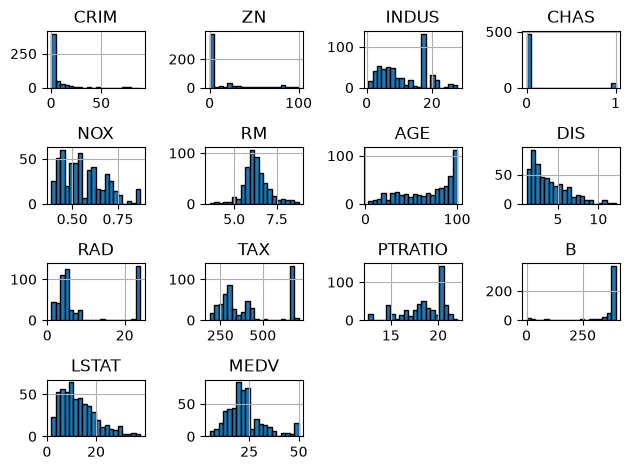

In [53]:



# Histograma de cada variable numérica
plt.figure(figsize=(18, 12))
df_filtrado.hist(bins=20, edgecolor='black')
plt.tight_layout()
#plt.savefig('./outputs/histogramas_variables_post_imputacion.png', dpi=200)
plt.show()

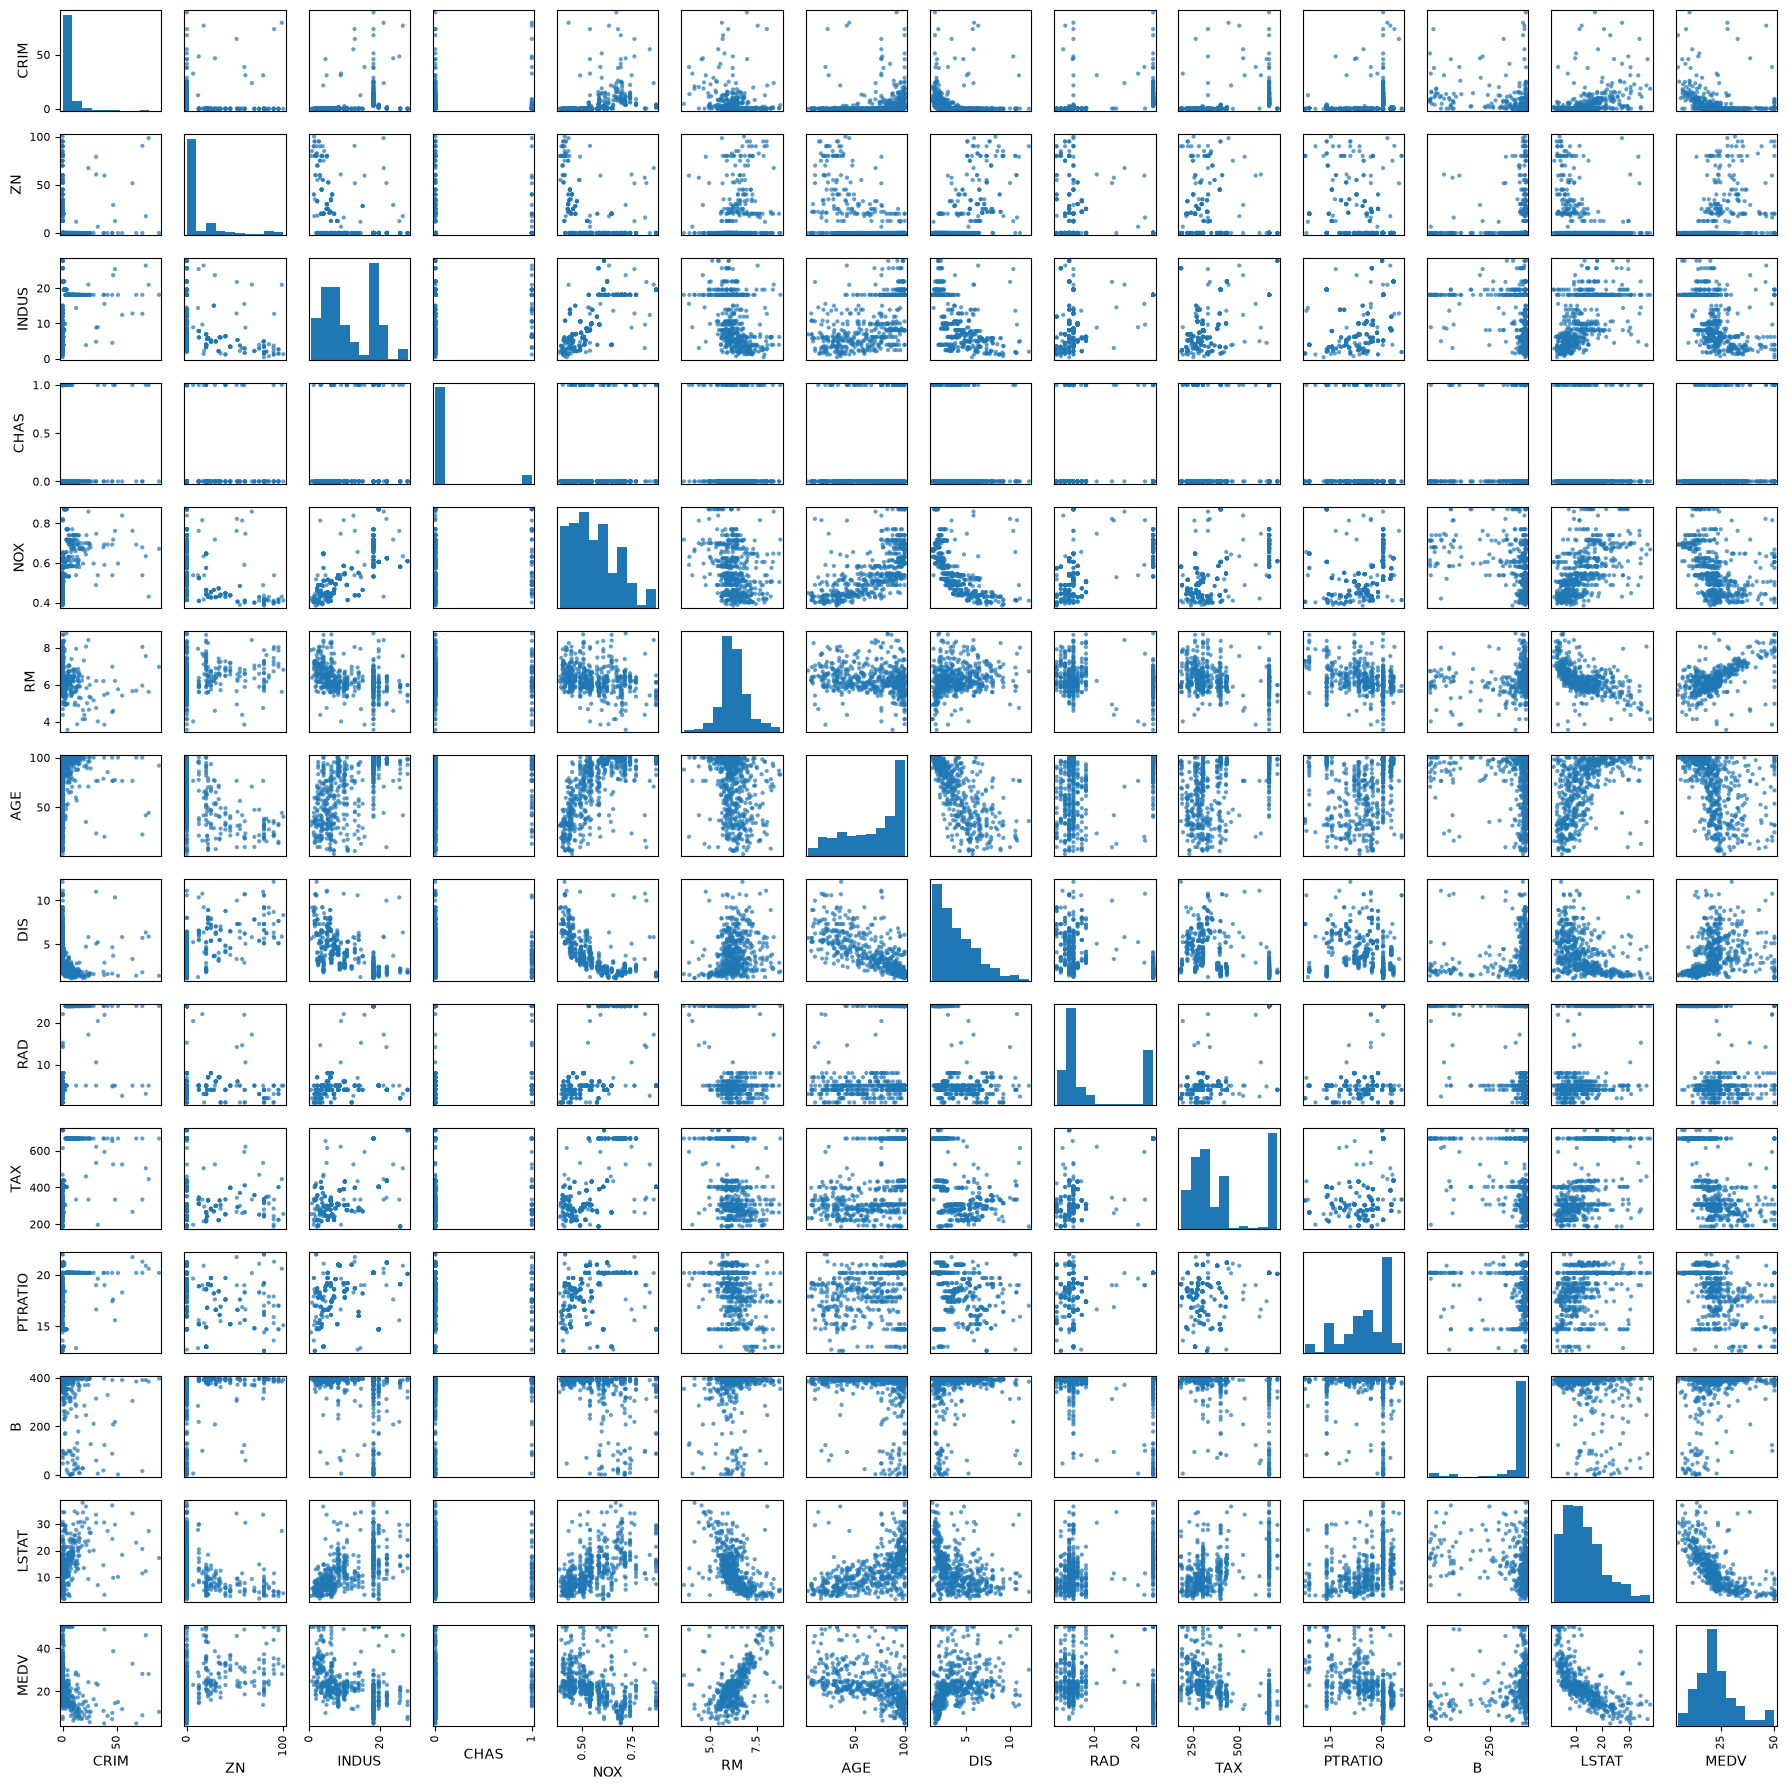

In [54]:


# Scatterplot entre variables numéricas
scatter_cols = df_filtrado.columns
pd.plotting.scatter_matrix(df_filtrado[scatter_cols], figsize=(18, 18), alpha=0.7, diagonal='hist')
plt.tight_layout()
#plt.savefig('./outputs/scatterplot_variables.png', dpi=200)
plt.show()

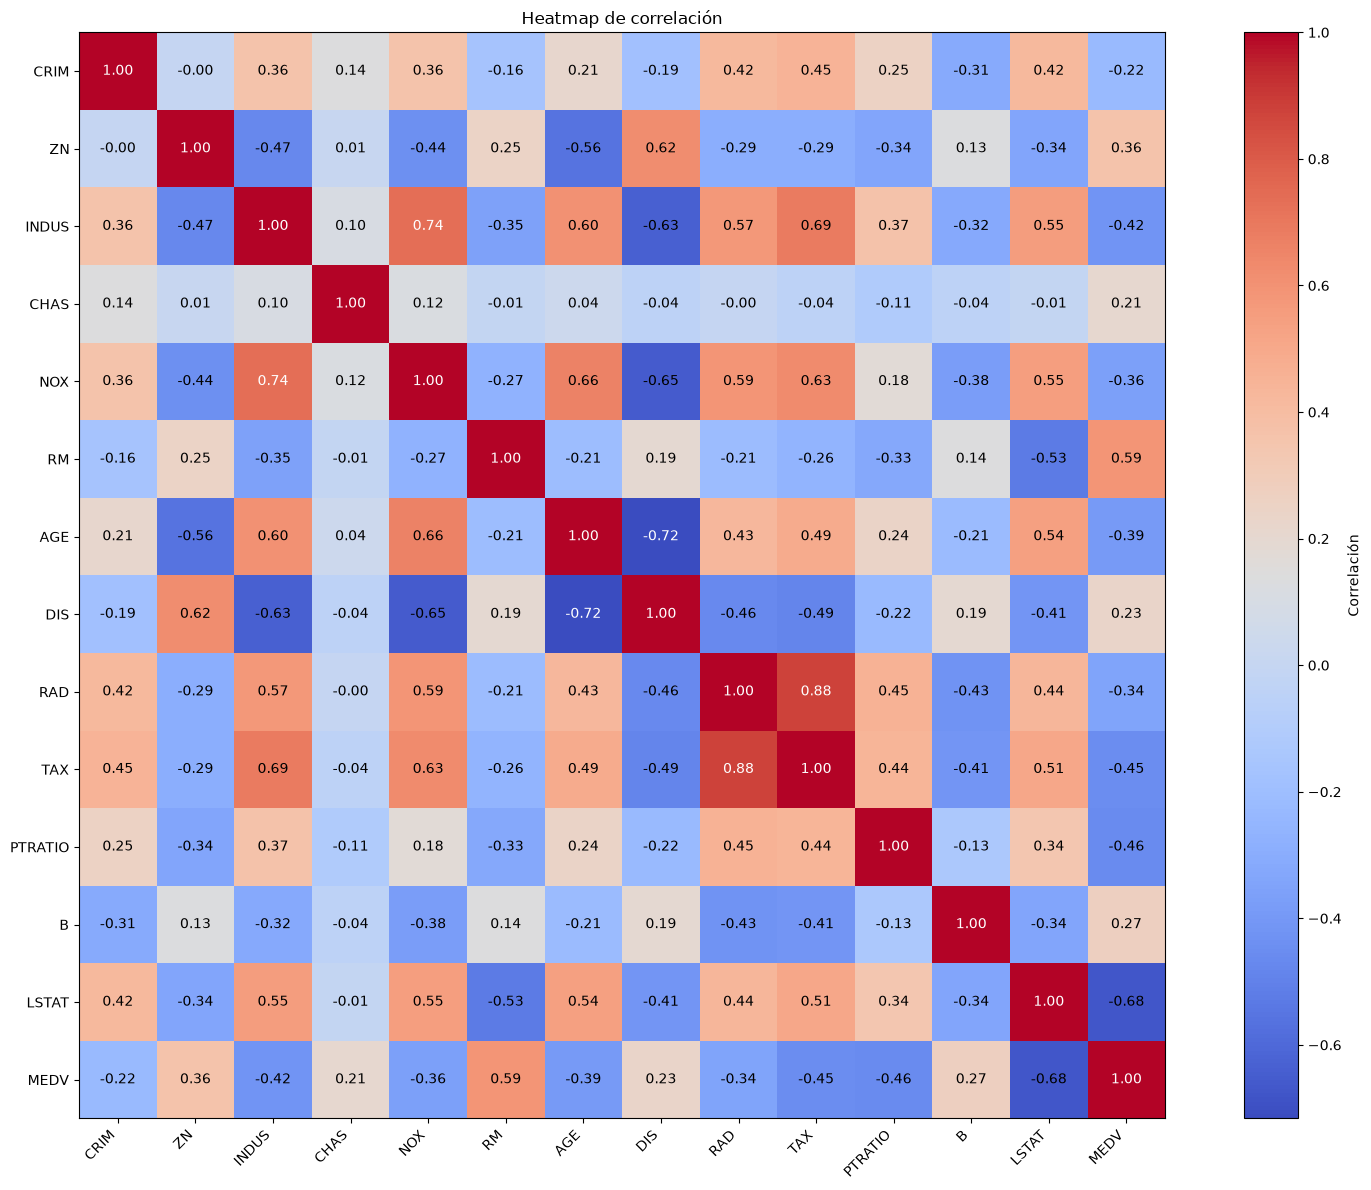

In [55]:

# Heatmap de correlación entre todas las variables
corr = df_filtrado.corr()
plt.figure(figsize=(16, 12))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlación')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white')
plt.title('Heatmap de correlación')
plt.tight_layout()
#plt.savefig('./outputs/heatmap_variables.png', dpi=200)
plt.show()

In [23]:
df = df[df['MEDV'].notnull()]

In [ ]:
print("#"*90)
print("Describe de df:")
print("#"*90)
print(df.describe().T)

#Verificamos si hay registros duplicados
duplicados = df.duplicated().sum()
print("#"*70)
print(f"Cantidad de registros duplicados: {duplicados}")

nulos_por_columna = df.isna().sum()
print("#"*70)
print("Cantidad de nulos por columna:")
print("#"*70)
print(nulos_por_columna)


nulos_por_fila = df.isna().sum(axis=1)
print("#"*70)
print("Cantidad de nulos por fila:")
print("#"*70)
print(nulos_por_fila.value_counts().sort_index())

# Filtra las filas que acumulan más de 5 NaN
filas_mas_5_nulos = df[df.isna().sum(axis=1) > 5]
print(" ")
print("#"*70)
print (f"Filas con más de 5 nulos: {len(filas_mas_5_nulos)}")
print("#"*70)
print(filas_mas_5_nulos)

#Removemos las filas con más de 5 nulos
df_filtrado = df.drop(filas_mas_5_nulos.index).reset_index(drop=True)

print("#"*70)
print("Información de df_filtrado (luego de remover filas con > 5 NaNs):")
print("#"*70)
df_filtrado.info()

print("#"*70)
print("Listado de registros MEDV sin precios (Target):")
print("#"*70)
print(df_filtrado[df_filtrado['MEDV'].isnull()])
#Removemos registros sin precios. Son pocos (4)
df_filtrado = df_filtrado.dropna(subset=['MEDV']).reset_index(drop=True)

print("#"*70)
print("info() de df_filtrado (se remueven registros MEDV=NaN)")
print("#"*70)
print(df_filtrado.info())
print("#"*70)
print("Describe de df_filtrado:")
print("#"*70)
print(df_filtrado.describe().T)

# Visualización de la distribución de la variable objetivo (MEDV)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["MEDV"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distribución de MEDV")
sns.boxplot(x=df["MEDV"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de MEDV")
plt.tight_layout()
plt.savefig('./outputs/distribucion_medv_pre_imputacion.png', dpi=200)
plt.show()

# Histograma de cada variable numérica
plt.figure(figsize=(18, 12))
df.hist(bins=20, edgecolor='black')
plt.tight_layout()
plt.savefig('./outputs/histogramas_variables_pre_imputacion.png', dpi=200)
plt.show()


#A los valores faltanes se les imputa el valor de sus medianas
df_filtrado = df_filtrado.fillna(df_filtrado.median())
print("#"*70)
print("info() de df_filtrado imputando medianas")
print("#"*70)
print(df_filtrado.info())
print("#"*70)
print("Describe de df_filtrado imputando medianas")
print("#"*70)
print(df_filtrado.describe().T)
print("#"*70)


# Visualización de la distribución de la variable objetivo (MEDV)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["MEDV"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Distribución de MEDV")
sns.boxplot(x=df["MEDV"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de MEDV")
plt.tight_layout()
plt.savefig('./outputs/distribucion_medv_post_imputacion.png', dpi=200)
plt.show()

# Histograma de cada variable numérica
plt.figure(figsize=(18, 12))
df.hist(bins=20, edgecolor='black')
plt.tight_layout()
plt.savefig('./outputs/histogramas_variables_post_imputacion.png', dpi=200)
plt.show()

# Scatterplot entre variables numéricas
scatter_cols = df.columns
pd.plotting.scatter_matrix(df[scatter_cols], figsize=(18, 18), alpha=0.7, diagonal='hist')
plt.tight_layout()
#plt.savefig('./outputs/scatterplot_variables.png', dpi=200)
plt.show()

# Heatmap de correlación entre todas las variables
corr = df.corr()
plt.figure(figsize=(16, 12))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlación')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black' if abs(corr.iloc[i, j]) < 0.7 else 'white')
plt.title('Heatmap de correlación')
plt.tight_layout()
#plt.savefig('./outputs/heatmap_variables.png', dpi=200)
plt.show()

# Boxplot de cada variable para observar cuartiles y outliers
plt.figure(figsize=(18, 12))
df.boxplot(rot=45, patch_artist=True)
plt.title('Boxplot de cada variable')
plt.tight_layout()
#plt.savefig('./outputs/boxplot_variables.png', dpi=200)
plt.show()